# Supervised learning in astronomy: classification + regression (tabular ML)

In this tutorial we will work with a **tabular** dataset of astronomical sources and use it to:

- build a **classification** model (BD / LPV / YSO / Galaxy),
- then reuse the same workflow for **regression** (predicting a continuous target: stellar class for example),
- and discuss good practice: splitting, leakage, preprocessing, metrics, tuning, interpretability and reliability.


# 1) Load the dataset

We will load a parquet file containing a pre-made catalogue.

**Important idea:** most ML bugs are boring:
wrong column, wrong split, leakage or broken data types.
So we start with sanity checks.

In [17]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = r"C:\Git projects\PhDSchool2026Napoli\AI-in-astro-tutorial-supervised\Prelim_balanced_catalogue_PS1_with_cut_2MASS_WISE_newUCD.parquet"

# DATA_PATH = "https://github.com/iamaleksandra/AI-in-astro-tutorial-supervised/raw/main/data/Prelim_balanced_catalogue_PS1_with_cut_2MASS_WISE_newUCD.parquet"

df = pd.read_parquet(DATA_PATH)
df.head()

,RAJ2000,DEJ2000,Class,gmag,e_gmag,rmag,e_rmag,imag,e_imag,zmag,...,W1,W1err,W2,W2err,Jmag,e_Jmag,Hmag,e_Hmag,Kmag,e_Kmag
0,266.38238,-24.27142,Var,20.4466,0.0072,17.7346,0.0208,14.8988,0.0224,12.6510,...,6.915,0.010,7.537,0.013,9.672,0.027,8.399,0.049,7.759,0.033
1,304.21691,30.94242,Var,16.4922,0.0075,14.2077,0.0014,12.1450,NaN,11.1020,...,6.653,0.016,6.788,0.008,8.651,0.021,7.393,0.024,6.916,0.020
2,359.68844,55.66797,Var,15.5176,0.0104,13.7179,0.0016,11.5198,0.0422,11.9317,...,6.476,0.019,6.063,0.010,7.616,0.024,6.638,0.055,6.204,0.017
3,6.99508,47.69643,Var,14.4898,0.0190,12.3170,NaN,10.5530,NaN,9.5100,...,6.255,0.024,5.816,0.011,7.256,0.021,6.351,0.023,5.945,0.017
4,286.07637,-9.41763,Var,20.0832,0.0406,17.1633,0.1090,12.5760,NaN,11.4200,...,7.208,0.022,6.460,0.009,8.898,0.030,7.814,0.047,7.193,0.038


In [3]:
# Basic info
display(df.sample(5, random_state=RANDOM_STATE))
print("\nColumns:", len(df.columns))
display(df.dtypes.value_counts())

,RAJ2000,DEJ2000,Class,gmag,e_gmag,rmag,e_rmag,imag,e_imag,zmag,...,W1,W1err,W2,W2err,Jmag,e_Jmag,Hmag,e_Hmag,Kmag,e_Kmag
9923,305.211050,39.804870,canYSO,28.9740,NaN,25.0830,NaN,22.0790,NaN,20.9055,...,12.895,0.035,12.618,0.041,16.398,NaN,14.846,0.083,14.054,0.078
7013,133.823393,5.966581,Galaxy,NaN,NaN,NaN,NaN,19.3655,0.0432,19.4706,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4779,84.966700,-0.983800,UCD,NaN,NaN,21.2317,0.0542,19.0754,0.1091,17.1562,...,11.891,0.012,11.604,0.009,14.033,0.031,13.104,0.024,12.527,0.024
1950,275.680000,-22.467610,Var,20.7303,0.0631,17.8014,0.0108,14.5212,0.0015,13.7009,...,6.974,0.020,6.724,0.010,10.177,0.023,8.754,0.036,7.922,0.023
2513,284.995830,-11.243200,Var,16.4896,0.0592,14.5304,0.0368,13.3100,NaN,11.6680,...,7.148,0.018,7.010,0.010,8.513,0.020,7.470,0.042,7.061,0.031



Columns: 23


float64    22
object      1
Name: count, dtype: int64

# 2) Train / Validation / Test Split

Before doing any preprocessing or modelling, we must split the data.

Why?

Because if we:
- scale using the full dataset,
- impute using the full dataset,
- tune hyperparameters using the full set,

we create **data leakage**. Leakage makes the model look better than it really is.

### Strategy

We will:

- Remove coordinates (RAJ2000, DEJ2000)
- Define X and y
- Use a **stratified split** (important for multi-class classification)
- Create:
    - Train (60%)
    - Validation (20%)
    - Test (20%)

We keep the test set untouched until the very end.

In [4]:
LABEL_COL = 'Class'

y_str = df[LABEL_COL]

# Encode to integers 0..K-1
le = LabelEncoder()
y = le.fit_transform(y_str)

# Save mapping for later interpretation
class_names = list(le.classes_)
class_mapping = dict(zip(class_names, range(len(class_names))))

# Drop label from features
X = df.drop(columns=[LABEL_COL, 'RAJ2000', 'DEJ2000'])

print("X shape:", X.shape)
display(y_str.value_counts(dropna=False).head(20))

X shape: (10246, 20)


Class
Var       4000
UCD       2831
canYSO    2147
Galaxy    1268
Name: count, dtype: int64

In [5]:
# First split: train+val vs test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# Second split: train vs val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25, 
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Train size:", X_train.shape)
print("Val size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (6147, 20)
Val size: (2049, 20)
Test size: (2050, 20)


## Why do we need a validation set?

If we only split into **train** and **test**, this works only if we train once and never adjust anything.

But in practice we always:
- tune hyperparameters
- compare models
- change preprocessing
- engineer features

If we look at the test performance and then modify the model, the test set has influenced model design and it is no longer a true test set.


### Roles of each split

- **Train** --> fit model parameters  
- **Validation/calibration** --> choose hyperparameters and make decisions OR for calibration in conformal predictions (we will see later)  
- **Test** --> final, unbiased evaluation  

The test set must simulate unseen future data, if it influences training, performance estimates become optimistic.

### What if we have limited data?

Instead of using a fixed validation set, we can use **k-fold cross-validation**.

How it works:

1. Split the training data into k folds.
2. Train on (k−1) folds.
3. Validate on the remaining fold.
4. Repeat k times.
5. Average the validation performance.

This allows every sample to be used for both training and validation.

Cross-validation replaces the **validation set**, but **not the test set**.

! We still keep a final test set untouched for one final evaluation.

# 3) Data preprocessing (scaling and missing values) and feature engineering

Before training any model, we must prepare the data.

For tabular astronomical data, preprocessing usually includes:

1. Handling missing values  
2. Feature scaling (for some models)  
3. Feature engineering (e.g. colors)  

Important principle:

All preprocessing steps must be fitted ONLY on the training set.
Validation and test sets must be transformed using parameters learned from training.

In [15]:
train_with_class = X_train.copy()
train_with_class["Class"] = le.inverse_transform(y_train)

missing_by_class = (
    X_train.isna()
    .groupby(train_with_class["Class"])
    .mean()
    .T
)

missing_by_class

Class,Galaxy,UCD,Var,canYSO
gmag,0.138158,0.920541,0.112500,0.545807
e_gmag,0.239474,0.920541,0.258750,0.916925
rmag,0.096053,0.785756,0.092083,0.443323
e_rmag,0.185526,0.785756,0.395000,0.673913
imag,0.000000,0.544438,0.000000,0.000000
e_imag,0.125000,0.544438,0.531667,0.061335
zmag,0.084211,0.377869,0.041250,0.009317
e_zmag,0.265789,0.377869,0.693333,0.022516
ymag,0.000000,0.327840,0.000000,0.000000
e_ymag,0.328947,0.327840,0.600000,0.013199


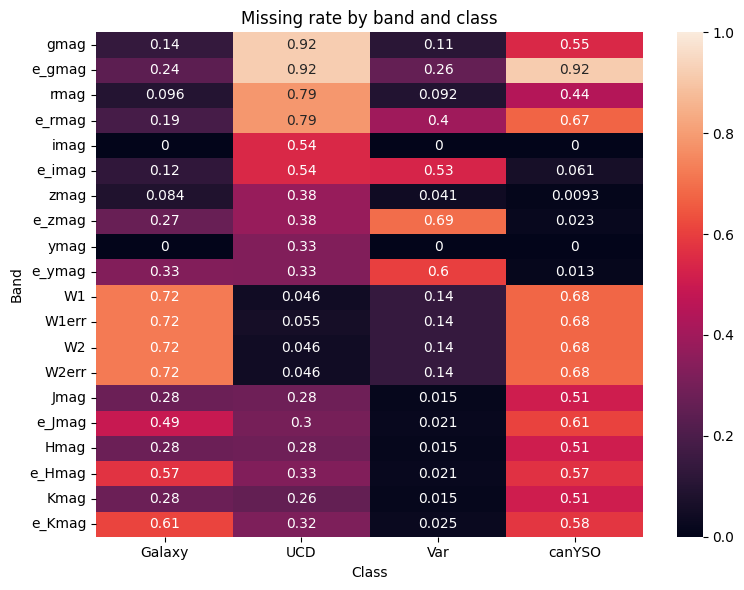

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(missing_by_class, annot=True, cmap="rocket", vmin=0, vmax=1)
plt.xlabel("Class")
plt.ylabel("Band")
plt.title("Missing rate by band and class")
plt.tight_layout()
plt.show()

## Interpretation: missingness is not random

The table above shows the fraction of missing values per feature and per class.

We observe that missingness strongly depends on class:

- UCDs are mostly missing in optical bands (g, r, i),
  but almost complete in W1/W2.
- Galaxies show the opposite behaviour:
  optical mostly present, W1/W2 mostly missing.
- YSO and Variables have different missing patterns again.

This means missingness is structured, not random.


### Why this matters

If missing values depend on class, then missingness itself contains information.

For example:
- "W1 missing" might correlate with Galaxy.
- "optical missing" might correlate with UCD.

If we blindly impute values without thinking,
the model may learn survey coverage patterns
instead of astrophysical differences.

This is not necessarily wrong statistically,
but it may reflect selection effects rather than physics.

### Practical implication

We have three options:

1. Ignore missingness (simple imputation).
2. Add missing-value indicators.
3. Restrict to bands available for all classes or objects that have no missing values.

### Feature engineering before preprocessing

Raw magnitudes depend strongly on distance. Two objects with identical physical properties but different distances
will have very different magnitudes. Therefore, training directly on raw magnitudes can lead the model to learn
distance effects rather than intrinsic physical differences.

Solution: use colors

A color is a difference between magnitudes, e.g.:

    g - r
    J - H
    W1 - W2

Colors are approximately distance-independent, because the distance modulus cancels out.

Therefore, the first step is to construct physically meaningful features before any imputation or scaling.

In [22]:
def add_all_colors(df):
    df = df.copy()

    df["g_r"] = df["gmag"] - df["rmag"]
    df["r_i"] = df["rmag"] - df["imag"]
    df["i_z"] = df["imag"] - df["zmag"]
    df["z_y"] = df["zmag"] - df["ymag"]

    df["J_H"] = df["Jmag"] - df["Hmag"]
    df["H_K"] = df["Hmag"] - df["Kmag"]

    df["W1_W2"] = df["W1"] - df["W2"]

    df["z_J"] = df["zmag"] - df["Jmag"]
    df["y_J"] = df["ymag"] - df["Jmag"]

    df["J_W1"] = df["Jmag"] - df["W1"]
    df["H_W1"] = df["Hmag"] - df["W1"]
    df["K_W1"] = df["Kmag"] - df["W1"]

    return df

X_train_c = add_all_colors(X_train)
X_val_c = add_all_colors(X_val)
X_test_c  = add_all_colors(X_test)

Missingness in this dataset is strongly class-dependent, as we already have seen.

Instead of hiding missing values through imputation, we will encode missingness as information.

Strategy:

1. Add binary indicators showing which original magnitudes were missing.
2. Impute missing colors (median, but I will show a couple of other methods).
4. Keep:
   - color features
   - missing indicators of original bands

This allows the model to retain structured missingness information.

In [29]:
from sklearn.impute import SimpleImputer

In [23]:
all_cols = list(X_train_c.columns)

imputer = SimpleImputer(strategy="median", add_indicator=True)

Xtr_arr = imputer.fit_transform(X_train_c[all_cols]) # <-- fit only on train data 
Xva_arr = imputer.transform(X_val_c[all_cols])
Xte_arr = imputer.transform(X_test_c[all_cols])

In [24]:
out_cols = imputer.get_feature_names_out(all_cols)

Xtr = pd.DataFrame(Xtr_arr, columns=out_cols, index=X_train_c.index)
Xva = pd.DataFrame(Xva_arr, columns=out_cols, index=X_val_c.index)
Xte = pd.DataFrame(Xte_arr, columns=out_cols, index=X_test_c.index)

In [25]:
Xtr.columns

Index(['gmag', 'e_gmag', 'rmag', 'e_rmag', 'imag', 'e_imag', 'zmag', 'e_zmag',
       'ymag', 'e_ymag', 'W1', 'W1err', 'W2', 'W2err', 'Jmag', 'e_Jmag',
       'Hmag', 'e_Hmag', 'Kmag', 'e_Kmag', 'g_r', 'r_i', 'i_z', 'z_y', 'J_H',
       'H_K', 'W1_W2', 'z_J', 'y_J', 'J_W1', 'H_W1', 'K_W1',
       'missingindicator_gmag', 'missingindicator_e_gmag',
       'missingindicator_rmag', 'missingindicator_e_rmag',
       'missingindicator_imag', 'missingindicator_e_imag',
       'missingindicator_zmag', 'missingindicator_e_zmag',
       'missingindicator_ymag', 'missingindicator_e_ymag',
       'missingindicator_W1', 'missingindicator_W1err', 'missingindicator_W2',
       'missingindicator_W2err', 'missingindicator_Jmag',
       'missingindicator_e_Jmag', 'missingindicator_Hmag',
       'missingindicator_e_Hmag', 'missingindicator_Kmag',
       'missingindicator_e_Kmag', 'missingindicator_g_r',
       'missingindicator_r_i', 'missingindicator_i_z', 'missingindicator_z_y',
       'missingindicat

In [27]:
color_cols = [
    "g_r", "r_i", "i_z", "z_y",
    "J_H", "H_K", "W1_W2",
    "z_J", "y_J",
    "J_W1", "H_W1", "K_W1"
]

mag_indicator_cols = [
    "missingindicator_gmag",
    "missingindicator_rmag",
    "missingindicator_imag",
    "missingindicator_zmag",
    "missingindicator_ymag",
    "missingindicator_Jmag",
    "missingindicator_Hmag",
    "missingindicator_Kmag",
    "missingindicator_W1",
    "missingindicator_W2",
]

X_train_use = Xtr[color_cols + mag_indicator_cols]
X_val_use = Xva[color_cols + mag_indicator_cols]
X_test_use  = Xte[color_cols + mag_indicator_cols]

print("Number of color features:", len(color_cols))
print("Number of missing indicators:", len(mag_indicator_cols))
print("Total features:", X_train_use.shape[1])

Number of color features: 12
Number of missing indicators: 10
Total features: 22


## Why do we need feature scaling?

Our color features have different numerical ranges.

For example:
- Some colors vary roughly between -1 and 5
- Others may span larger ranges

If features have different scales, some models will treat large-scale features as more important purely because of magnitude.


### When scaling is necessary

Scaling is important for models that depend on:

- Distances (KNN)
- Dot products (SVM, logistic regression)
- Gradient-based optimisation (neural networks)

These models are sensitive to feature magnitude.


### When scaling is NOT necessary

Tree-based models (Decision Trees, Random Forest, Gradient Boosting)
are based on feature splits, not distances.
They are largely insensitive to feature scaling.


### What we will do

We scale continuous color features, but we do not scale binary missing indicators, as they already have a meaningful 0/1 interpretation.

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [30]:
scaler = ColumnTransformer(
    transformers=[
        ("scale_colors", StandardScaler(), color_cols),
        ("keep_indicators", "passthrough", mag_indicator_cols),
    ],
    remainder="drop"
)

X_train_prep = scaler.fit_transform(X_train_use)
X_val_prep = scaler.transform(X_val_use)
X_test_prep  = scaler.transform(X_test_use)

print("Shapes after scaling:")
print("Train:", X_train_prep.shape)
print("Val:  ", X_val_prep.shape)
print("Test: ", X_test_prep.shape)

Shapes after scaling:
Train: (6147, 22)
Val:   (2049, 22)
Test:  (2050, 22)


### Now that the data is prepared, we can train our first classifier.

In [42]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=10)
knn_clf.fit(X_train_prep, y_train)
y_pred = knn_clf.predict(X_test_prep)
y_pred

array([2, 2, 3, ..., 2, 3, 2], shape=(2050,))

The model now assigns a predicted class to each object in the test set.

However, predictions alone do not tell us whether the classifier is performing well.
To evaluate the quality of the model, we need appropriate classification metrics.

## 4) Classification metrics

For multi-class classification, we use several complementary metrics:

- Confusion matrix
- Accuracy
- Precision (macro)
- Recall (macro)
- F1-score (macro)
- ROC-AUC (one-vs-rest)

Each metric captures a different aspect of model performance, so it is better to interpret them together rather than rely on a single number.

### Confusion matrix

The confusion matrix compares the true labels with the predicted labels.

In a multi-class problem, the diagonal elements correspond to correctly classified objects, while the off-diagonal elements indicate misclassifications. This makes the confusion matrix especially useful for identifying which classes are most often confused with one another.

### Accuracy

Accuracy is the fraction of correctly classified objects among all objects:

$$
\mathrm{Accuracy} = \frac{\text{number of correct predictions}}{\text{total number of predictions}}
$$

Accuracy is easy to interpret, but it can be misleading for imbalanced datasets. A model may obtain high accuracy simply by performing well on the majority class, while still performing poorly on minority classes.

### Precision (macro)

Precision measures how reliable the positive predictions are. For a given class:

$$
\mathrm{Precision} = \frac{TP}{TP + FP}
$$

where:

- $TP$ = true positives
- $FP$ = false positives

High precision means that when the model predicts a class, that prediction is usually correct.

For multi-class classification, **macro-precision** is computed by calculating precision separately for each class and then averaging across all classes:

$$
\mathrm{Precision}_{\mathrm{macro}} = \frac{1}{K}\sum_{i=1}^{K}\mathrm{Precision}_i
$$

where $K$ is the number of classes.

### Recall (macro)

Recall measures how many objects of a given class are correctly identified:

$$
\mathrm{Recall} = \frac{TP}{TP + FN}
$$

where $FN$ = false negatives.

High recall means that the model misses only a small fraction of objects belonging to that class.

For multi-class classification, **macro-recall** is:

$$
\mathrm{Recall}_{\mathrm{macro}} = \frac{1}{K}\sum_{i=1}^{K}\mathrm{Recall}_i
$$

This metric is particularly important when minority classes are of interest.

<figure style="text-align: center;">
  <img src="images/Precisionrecall.svg" width="300">
  <figcaption>
    </em> Precision and recall diagram showing true positives, false positives, and false negatives.
    Image by <a href="//commons.wikimedia.org/wiki/User:Walber" title="User:Walber">Walber</a>,
    own work,
    licensed under
    <a href="https://creativecommons.org/licenses/by-sa/4.0" title="Creative Commons Attribution-Share Alike 4.0">CC BY-SA 4.0</a>.
    <a href="https://commons.wikimedia.org/w/index.php?curid=36926283">Source</a>.
  </figcaption>
</figure>

### F1-score (macro)

The F1-score combines precision and recall through their harmonic mean:

$$
F1 = 2 \cdot \frac{\mathrm{Precision} \cdot \mathrm{Recall}}{\mathrm{Precision} + \mathrm{Recall}}
$$

A high F1-score indicates a good balance between avoiding false positives and false negatives.

For multi-class classification, **macro-F1** is obtained by averaging the F1-score over all classes:

$$
F1_{\mathrm{macro}} = \frac{1}{K}\sum_{i=1}^{K}F1_i
$$

This is often more informative than accuracy when working with imbalanced datasets.

### ROC-AUC (one-vs-rest)

<figure style="text-align: center;">
  <img src="images/Roc_curve.svg" width="300">
  <figcaption>
    </em> Example ROC curves illustrating different levels of classifier performance.
    Image by
    <a href="https://commons.wikimedia.org/wiki/User:Cmglee">cmglee</a>
    and
    <a href="https://commons.wikimedia.org/wiki/User:MartinThoma">MartinThoma</a>,
    licensed under
    <a href="https://creativecommons.org/licenses/by-sa/4.0">CC BY-SA 4.0</a>.
    <a href="https://commons.wikimedia.org/w/index.php?curid=109730045">Source</a>.
  </figcaption>
</figure>

The ROC (Receiver Operating Characteristic) curve shows the trade-off between the true positive rate and the false positive rate at different decision thresholds.

The **area under the ROC curve (AUC)** summarizes this curve with a single number. It measures how well the classifier separates the positive and negative classes across all possible thresholds. An AUC value close to 1 indicates strong class separability, while an AUC value close to 0.5 corresponds to near-random performance.

For multi-class classification, ROC-AUC is commonly computed using the **one-vs-rest** approach. In this setting, each class is treated in turn as the positive class, while all remaining classes are grouped together as the negative class. An ROC curve and the corresponding AUC are then computed for each class.

### Why macro-averaging?

Macro-averaging gives equal weight to each class, regardless of how many examples belong to that class.

This is important because our dataset is imbalanced. If we used only overall metrics, the performance on majority classes could dominate the result and hide poor performance on minority classes. Macro-averaged metrics therefore provide a more balanced evaluation across the full set of classes.

In [43]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)

In [ ]:
# numeric labels 0..3 in the encoder order
labels_sorted = list(range(len(le.classes_)))
class_names = list(le.classes_)  # axis labels in same order as labels_sorted

def evaluate_model(name, model, X_val, y_val, normalize_cm=False):
    """
    y_val must be encoded ints (0..K-1).
    Confusion matrix will display class names (strings).
    """
    y_pred = model.predict(X_val)

    y_proba = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)

    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average="macro", labels=labels_sorted, zero_division=0)
    rec = recall_score(y_val, y_pred, average="macro", labels=labels_sorted, zero_division=0)
    f1 = f1_score(y_val, y_pred, average="macro", labels=labels_sorted, zero_division=0)

    print(f"\n{name}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"Macro-F1:  {f1:.4f}")

    if y_proba is not None:
        auc = roc_auc_score(y_val, y_proba, multi_class="ovr")
        print(f"ROC-AUC (OvR): {auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred, labels=labels_sorted)

    if normalize_cm:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize_cm else "d",
        cmap="Blues",
        cbar=True,
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion matrix{' (normalized)' if normalize_cm else ''}")
    plt.tight_layout()
    plt.show()

# 5) Classification models


KNN
Accuracy:  0.9292
Precision: 0.9277
Recall:    0.9182
Macro-F1:  0.9226
ROC-AUC (OvR): 0.9831


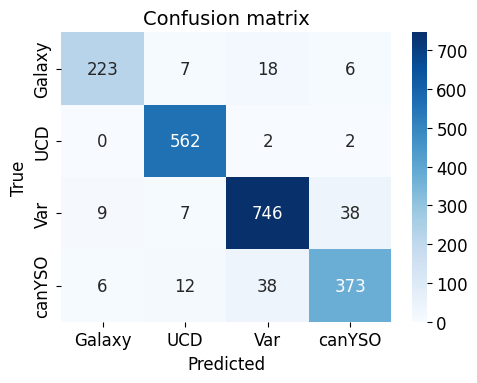

In [98]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train_prep, y_train)

evaluate_model("KNN", knn, X_val_prep, y_val)

try to change the number of neighbours, what do you notice?


KNN
Accuracy:  0.3904
Precision: 0.0976
Recall:    0.2500
Macro-F1:  0.1404
ROC-AUC (OvR): 0.7341


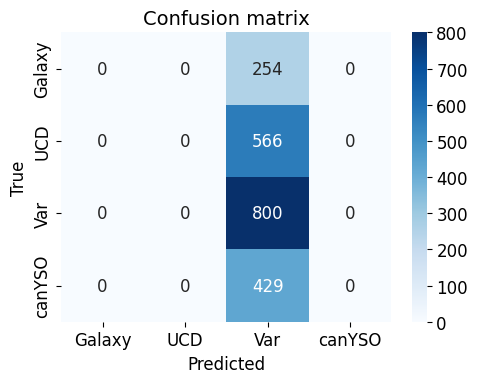

In [116]:
knn_high_number = KNeighborsClassifier(n_neighbors=6000)
knn_high_number.fit(X_train_prep, y_train)

evaluate_model("KNN", knn_high_number, X_val_prep, y_val)

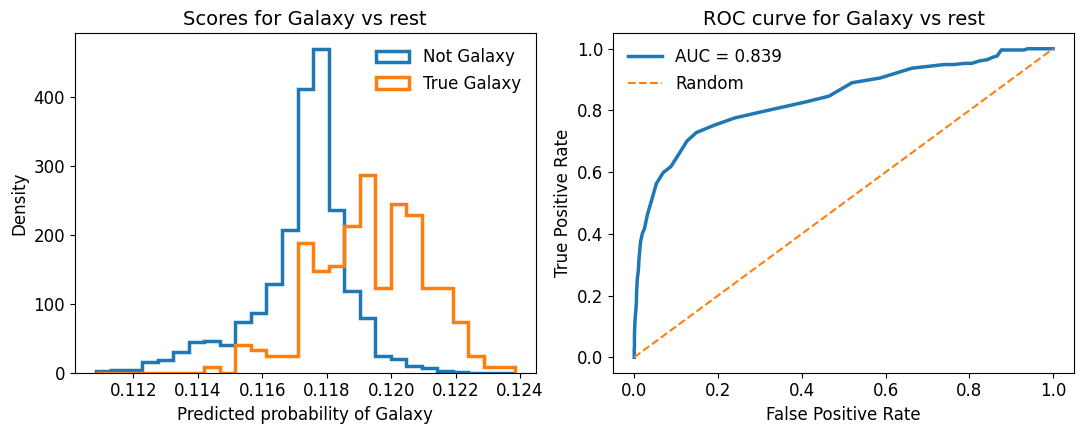

In [117]:
from sklearn.metrics import roc_curve, roc_auc_score

# Choose class
target_name = "Galaxy"
target_id = le.transform([target_name])[0]

# Predicted probabilities
y_proba = knn_high_number.predict_proba(X_val_prep)

# Binary truth for one-vs-rest
y_true_bin = (y_val == target_id).astype(int)

# Scores for the chosen class
y_score = y_proba[:, target_id]

# ROC data
fpr, tpr, _ = roc_curve(y_true_bin, y_score)
auc_val = roc_auc_score(y_true_bin, y_score)

# Split scores for left panel
target_scores_true = y_score[y_true_bin == 1]
target_scores_rest = y_score[y_true_bin == 0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: score distributions
bins = np.linspace(y_score.min(), y_score.max(), 28)
axes[0].hist(
    target_scores_rest,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2.5,
    label=f"Not {target_name}"
)
axes[0].hist(
    target_scores_true,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2.5,
    label=f"True {target_name}"
)
axes[0].set_title(f"Scores for {target_name} vs rest")
axes[0].set_xlabel(f"Predicted probability of {target_name}")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False)

# Right: ROC curve
axes[1].plot(fpr, tpr, linewidth=2.5, label=f"AUC = {auc_val:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random")
axes[1].set_title(f"ROC curve for {target_name} vs rest")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

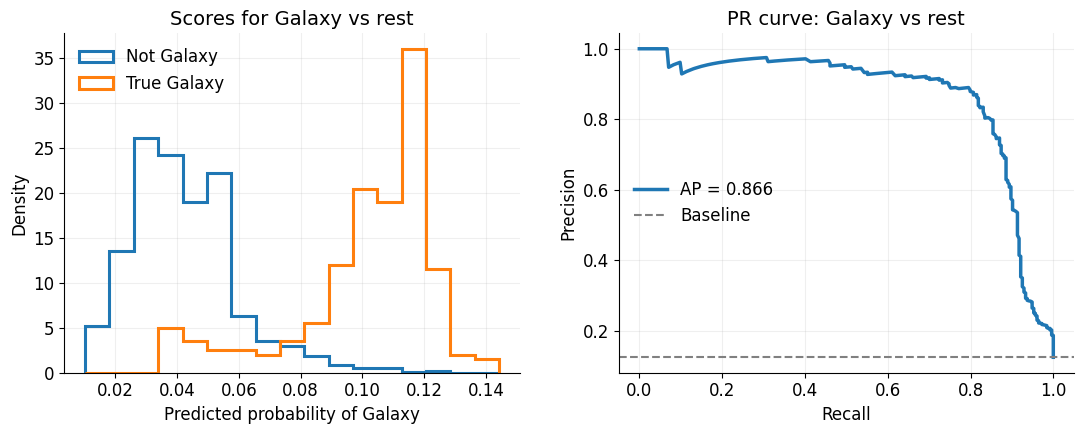

In [95]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Choose class
target_name = "Galaxy"
target_id = le.transform([target_name])[0]

# Predicted probabilities
y_proba = knn.predict_proba(X_val_prep)

# Binary truth for one-vs-rest
y_true_bin = (y_val == target_id).astype(int)

# Scores for chosen class
y_score = y_proba[:, target_id]

# PR data
precision, recall, _ = precision_recall_curve(y_true_bin, y_score)
ap_val = average_precision_score(y_true_bin, y_score)

# For left panel
scores_true = y_score[y_true_bin == 1]
scores_rest = y_score[y_true_bin == 0]

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

bins = np.linspace(y_score.min(), y_score.max(), 18)

# Left panel: score distributions
axes[0].hist(scores_rest, bins=bins, density=True, histtype="step", linewidth=2.2,
             label=f"Not {target_name}")
axes[0].hist(scores_true, bins=bins, density=True, histtype="step", linewidth=2.2,
             label=f"True {target_name}")
axes[0].set_title(f"Scores for {target_name} vs rest")
axes[0].set_xlabel(f"Predicted probability of {target_name}")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.2)

# Right panel: PR curve
axes[1].plot(recall, precision, linewidth=2.5, label=f"AP = {ap_val:.3f}")
baseline = y_true_bin.mean()
axes[1].axhline(baseline, linestyle="--", color="gray", linewidth=1.5, label="Baseline")
axes[1].set_title(f"PR curve: {target_name} vs rest")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.2)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Although the one-vs-rest ROC curve for `Galaxy` looks relatively strong, the confusion matrix shows that the classifier still rarely predicts `Galaxy` as the final class. This is because one-vs-rest evaluation measures how well the model ranks `Galaxy` objects above non-`Galaxy` objects using the score `P(Galaxy)`, whereas the confusion matrix reflects the final multiclass decision based on the largest predicted probability. A class can therefore have good one-vs-rest ranking performance while still losing the top-1 prediction to another class, such as `Var`.

This example shows that different evaluation metrics capture different aspects of model performance. One-vs-rest ROC-AUC measures how well the model ranks a given class against the rest, while the confusion matrix and macro-averaged metrics evaluate the final multiclass predictions. A classifier may therefore show good ranking performance for the class while still performing poorly as a whole.


Random Forest
Accuracy:  0.8853
Precision: 0.8899
Recall:    0.8561
Macro-F1:  0.8700
ROC-AUC (OvR): 0.9804


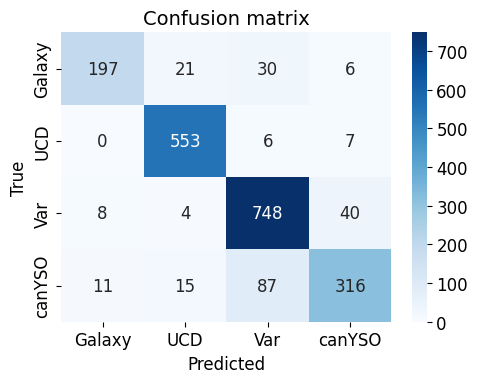

In [126]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,          
    min_samples_leaf=1,    
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_prep, y_train)

evaluate_model("Random Forest", rf, X_val_prep, y_val)


XGBoost
Accuracy:  0.9536
Precision: 0.9482
Recall:    0.9517
Macro-F1:  0.9497
ROC-AUC (OvR): 0.9942


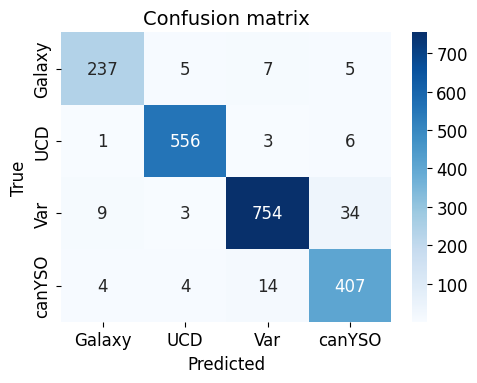

In [127]:
from xgboost import XGBClassifier

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train_prep, y_train_enc)

evaluate_model("XGBoost", xgb, X_val_prep, y_val) 


SVM (RBF)
Accuracy:  0.9341
Precision: 0.9273
Recall:    0.9267
Macro-F1:  0.9269
ROC-AUC (OvR): 0.9895


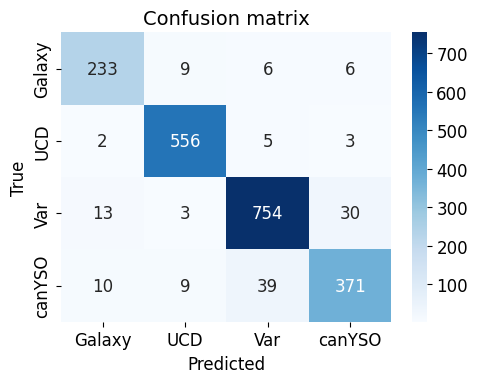

In [128]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", probability=True, random_state=42)
svm.fit(X_train_prep, y_train)

evaluate_model("SVM (RBF)", svm, X_val_prep, y_val)